# Day 27: IoT Sensor Anomaly Detector

**Industry:** Energy / Aerospace / Manufacturing  
**Format:** Jupyter Notebook (.ipynb)  
**Skills:** pandas · numpy · Z-score detection · rolling statistics · matplotlib · seaborn

**Data:** NASA CMAPSS Turbofan Engine Degradation Dataset  
100 engines · 21 sensors · 20,631 cycle readings · run-to-failure simulation  
Source: NASA Ames Prognostics Center of Excellence (phm-datasets.s3.amazonaws.com)

---

## Who uses this
A **predictive maintenance engineer** monitoring a fleet of industrial turbofan engines. This notebook processes real NASA sensor data to detect when engines start degrading — using rolling Z-scores and multi-sensor anomaly scoring to flag engines before they fail.

## What we build
1. Load real NASA CMAPSS sensor data
2. Identify informative vs constant sensors
3. Calculate Remaining Useful Life (RUL) per engine
4. Rolling Z-score anomaly detection per sensor
5. Multi-sensor composite health score per engine per cycle
6. Flag engines approaching failure
7. 4-panel seaborn dashboard
8. Export maintenance priority list

## Step 1 — Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
print('Libraries loaded successfully')

Libraries loaded successfully


## Step 2 — Load NASA CMAPSS Data

In [4]:
COLS = ['unit', 'cycle', 'op1', 'op2', 'op3'] + [f's{i}' for i in range(1, 22)]

df = pd.read_csv('nasa_data/train_FD001.txt', sep='\\s+', header=None, names=COLS)

print(f'Dataset:      NASA CMAPSS FD001 (Sea Level, HPC Degradation)')
print(f'Rows:         {len(df):,}')
print(f'Engines:      {df["unit"].nunique()}')
print(f'Sensors:      21 (s1–s21)')
print(f'Cycle range:  {df["cycle"].min()} to {df["cycle"].max()}')
print(f'\nLifespan per engine (cycles):')
lifespan = df.groupby('unit')['cycle'].max()
print(f'  Min: {lifespan.min()} | Max: {lifespan.max()} | Mean: {lifespan.mean():.0f}')
df.head(3)

Dataset:      NASA CMAPSS FD001 (Sea Level, HPC Degradation)
Rows:         20,631
Engines:      100
Sensors:      21 (s1–s21)
Cycle range:  1 to 362

Lifespan per engine (cycles):
  Min: 128 | Max: 362 | Mean: 206


,unit,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442


## Step 3 — Identify Informative Sensors

Some sensors are constant across all readings (zero variance) — they carry no degradation signal and should be excluded from anomaly detection.

In [5]:
sensor_cols = [f's{i}' for i in range(1, 22)]

# Coefficient of variation — sensors with very low variation are constant
sensor_cv = df[sensor_cols].std() / df[sensor_cols].mean().abs()
sensor_cv = sensor_cv.replace([np.inf, -np.inf], 0).fillna(0)

# Keep sensors with meaningful variation (CV > 0.001)
INFORMATIVE = sensor_cv[sensor_cv > 0.001].index.tolist()
CONSTANT    = [s for s in sensor_cols if s not in INFORMATIVE]

print(f'Informative sensors ({len(INFORMATIVE)}): {INFORMATIVE}')
print(f'Constant sensors    ({len(CONSTANT)}):    {CONSTANT}')
print(f'\nSensor coefficient of variation (sorted):')
print(sensor_cv.sort_values(ascending=False).round(4).to_string())

Informative sensors (11): ['s3', 's4', 's7', 's9', 's11', 's12', 's14', 's15', 's17', 's20', 's21']
Constant sensors    (10):    ['s1', 's2', 's5', 's6', 's8', 's10', 's13', 's16', 's18', 's19']

Sensor coefficient of variation (sorted):
s4     0.0064
s11    0.0056
s20    0.0047
s21    0.0046
s15    0.0044
s17    0.0039
s3     0.0039
s9     0.0024
s14    0.0023
s7     0.0016
s12    0.0014
s2     0.0008
s6     0.0001
s13    0.0000
s8     0.0000
s5     0.0000
s16    0.0000
s1     0.0000
s10    0.0000
s19    0.0000
s18    0.0000


## Step 4 — Calculate Remaining Useful Life (RUL)

RUL = cycles remaining before engine failure. In the training set, we know when each engine fails (last cycle). RUL at cycle t = max_cycle - t.

In [6]:
# RUL = max cycle for that engine minus current cycle
max_cycle = df.groupby('unit')['cycle'].max().reset_index()
max_cycle.columns = ['unit', 'max_cycle']
df = df.merge(max_cycle, on='unit')
df['rul'] = df['max_cycle'] - df['cycle']

# Health stage labels
def health_stage(rul):
    if rul <= 30:   return 'Critical (≤30 cycles)'
    elif rul <= 70: return 'Warning (31-70 cycles)'
    elif rul <= 125: return 'Caution (71-125 cycles)'
    else:           return 'Healthy (>125 cycles)'

df['health_stage'] = df['rul'].apply(health_stage)

print(f'RUL distribution:')
print(df['rul'].describe().round(1).to_string())
print(f'\nHealth stage distribution:')
print(df['health_stage'].value_counts().to_string())

RUL distribution:
count    20631.0
mean       107.8
std         68.9
min          0.0
25%         51.0
50%        103.0
75%        155.0
max        361.0

Health stage distribution:
health_stage
Healthy (>125 cycles)      8031
Caution (71-125 cycles)    5500
Warning (31-70 cycles)     4000
Critical (≤30 cycles)      3100


## Step 5 — Rolling Z-Score Anomaly Detection

For each informative sensor, we calculate a rolling Z-score (window=30 cycles) per engine. A reading more than 2.5 standard deviations from the rolling mean is flagged as anomalous. This mimics real IoT anomaly detection systems.

In [7]:
WINDOW    = 30
THRESHOLD = 2.5

df = df.sort_values(['unit', 'cycle']).reset_index(drop=True)

# Rolling Z-score per sensor per engine
for sensor in INFORMATIVE:
    rolling_mean = df.groupby('unit')[sensor].transform(
        lambda x: x.rolling(WINDOW, min_periods=5).mean()
    )
    rolling_std = df.groupby('unit')[sensor].transform(
        lambda x: x.rolling(WINDOW, min_periods=5).std()
    )
    df[f'z_{sensor}'] = ((df[sensor] - rolling_mean) / rolling_std.replace(0, np.nan)).round(3)

z_cols = [f'z_{s}' for s in INFORMATIVE]

# Composite anomaly score = mean absolute Z-score across all informative sensors
df['anomaly_score'] = df[z_cols].abs().mean(axis=1).round(3)
df['sensors_flagged'] = (df[z_cols].abs() > THRESHOLD).sum(axis=1)
df['is_anomaly'] = df['sensors_flagged'] > 0

# Engine-level health score = avg anomaly score in last 30 cycles
last30 = df.groupby('unit').tail(30)
engine_health = (
    last30.groupby('unit')
    .agg(
        last_cycle=('cycle', 'max'),
        rul=('rul', 'min'),
        avg_anomaly_score=('anomaly_score', 'mean'),
        pct_anomalous=('is_anomaly', 'mean'),
        health_stage=('health_stage', 'last'),
    )
    .round(3)
    .reset_index()
    .sort_values('avg_anomaly_score', ascending=False)
)

print(f'Rolling window:       {WINDOW} cycles')
print(f'Anomaly threshold:    Z > {THRESHOLD}')
print(f'Informative sensors:  {len(INFORMATIVE)}')
print(f'\nTop 15 engines by anomaly score (last 30 cycles):')
print(engine_health.head(15).to_string())
print(f'\nAnomaly rate by health stage:')
print(df.groupby('health_stage')['is_anomaly'].mean().mul(100).round(1).to_string())

Rolling window:       30 cycles
Anomaly threshold:    Z > 2.5
Informative sensors:  11

Top 15 engines by anomaly score (last 30 cycles):
    unit  last_cycle  rul  avg_anomaly_score  pct_anomalous           health_stage
81    82         214    0              1.307          0.033  Critical (≤30 cycles)
2      3         179    0              1.305          0.333  Critical (≤30 cycles)
50    51         213    0              1.294          0.267  Critical (≤30 cycles)
96    97         202    0              1.287          0.300  Critical (≤30 cycles)
17    18         195    0              1.279          0.300  Critical (≤30 cycles)
3      4         189    0              1.277          0.333  Critical (≤30 cycles)
8      9         201    0              1.246          0.167  Critical (≤30 cycles)
59    60         172    0              1.218          0.200  Critical (≤30 cycles)
40    41         216    0              1.213          0.200  Critical (≤30 cycles)
23    24         147    0       

## Step 6 — Visualise: 4-Panel Dashboard

Dashboard saved as sensor_anomaly_dashboard.png


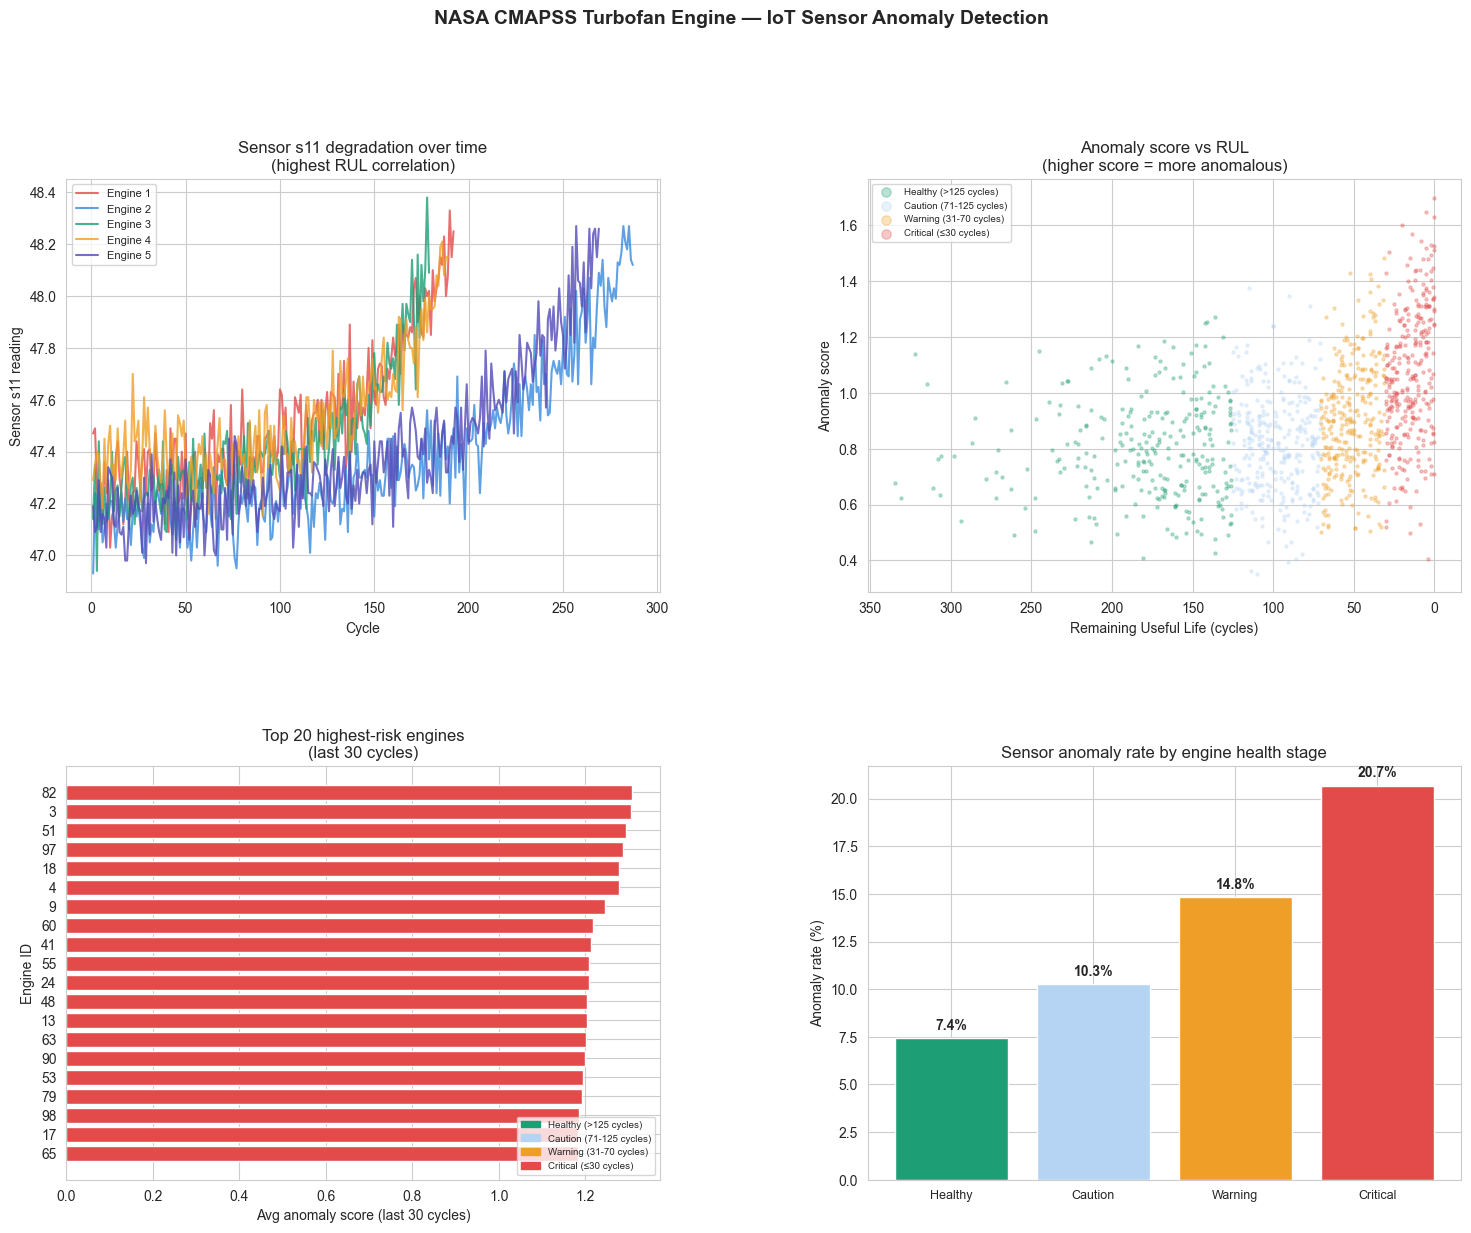

In [8]:
fig = plt.figure(figsize=(18, 13))
fig.suptitle('NASA CMAPSS Turbofan Engine — IoT Sensor Anomaly Detection',
             fontsize=14, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.35)

stage_colors = {
    'Healthy (>125 cycles)'   : '#1D9E75',
    'Caution (71-125 cycles)' : '#B5D4F4',
    'Warning (31-70 cycles)'  : '#EF9F27',
    'Critical (≤30 cycles)'   : '#E24B4A',
}

# Panel 1 — Sensor degradation over RUL for top sensor
ax1 = fig.add_subplot(gs[0, 0])
# Pick the sensor with highest correlation to RUL
correlations = df[INFORMATIVE].corrwith(df['rul']).abs()
top_sensor   = correlations.idxmax()
# Sample 5 engines for clarity
sample_units = df['unit'].unique()[:5]
colors_eng   = ['#E24B4A','#378ADD','#1D9E75','#EF9F27','#534AB7']
for unit, color in zip(sample_units, colors_eng):
    eng = df[df['unit'] == unit].sort_values('cycle')
    ax1.plot(eng['cycle'], eng[top_sensor], color=color, linewidth=1.5,
             alpha=0.8, label=f'Engine {unit}')
ax1.set_xlabel('Cycle')
ax1.set_ylabel(f'Sensor {top_sensor} reading')
ax1.set_title(f'Sensor {top_sensor} degradation over time\n(highest RUL correlation)')
ax1.legend(fontsize=8)

# Panel 2 — Anomaly score vs RUL scatter
ax2 = fig.add_subplot(gs[0, 1])
for stage, color in stage_colors.items():
    subset = df[df['health_stage'] == stage].sample(min(300, len(df[df['health_stage']==stage])))
    ax2.scatter(subset['rul'], subset['anomaly_score'],
                alpha=0.3, s=5, color=color, label=stage)
ax2.set_xlabel('Remaining Useful Life (cycles)')
ax2.set_ylabel('Anomaly score')
ax2.set_title('Anomaly score vs RUL\n(higher score = more anomalous)')
ax2.legend(fontsize=7, markerscale=3)
ax2.invert_xaxis()

# Panel 3 — Engine health score (last 30 cycles) ranked
ax3 = fig.add_subplot(gs[1, 0])
top20 = engine_health.head(20).sort_values('avg_anomaly_score')
bar_colors = [stage_colors.get(s, '#888') for s in top20['health_stage']]
ax3.barh(top20['unit'].astype(str), top20['avg_anomaly_score'], color=bar_colors)
ax3.set_xlabel('Avg anomaly score (last 30 cycles)')
ax3.set_title('Top 20 highest-risk engines\n(last 30 cycles)')
ax3.set_ylabel('Engine ID')
# Legend
import matplotlib.patches as mpatches
patches = [mpatches.Patch(color=c, label=s) for s, c in stage_colors.items()]
ax3.legend(handles=patches, fontsize=7, loc='lower right')

# Panel 4 — Anomaly rate by health stage
ax4 = fig.add_subplot(gs[1, 1])
stage_anomaly = df.groupby('health_stage')['is_anomaly'].mean().mul(100)
stage_order   = list(stage_colors.keys())
stage_anomaly = stage_anomaly.reindex(stage_order)
colors4       = [stage_colors[s] for s in stage_order]
bars4         = ax4.bar(range(len(stage_order)), stage_anomaly.values, color=colors4)
ax4.set_xticks(range(len(stage_order)))
ax4.set_xticklabels([s.split(' ')[0] for s in stage_order], fontsize=9)
ax4.set_ylabel('Anomaly rate (%)')
ax4.set_title('Sensor anomaly rate by engine health stage')
for bar, val in zip(bars4, stage_anomaly.values):
    ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.savefig('sensor_anomaly_dashboard.png', dpi=150, bbox_inches='tight')
print('Dashboard saved as sensor_anomaly_dashboard.png')
plt.show()

## Step 7 — Export + Business Insight Summary

In [9]:
os.makedirs('output', exist_ok=True)

engine_health.to_csv('output/engine_health_ranked.csv', index=False)
df[['unit','cycle','rul','health_stage','anomaly_score',
    'sensors_flagged','is_anomaly']].to_csv('output/all_readings_scored.csv', index=False)

# Maintenance priority list — critical and warning engines
priority = engine_health[engine_health['health_stage'].isin([
    'Critical (≤30 cycles)', 'Warning (31-70 cycles)'
])]
priority.to_csv('output/maintenance_priority.csv', index=False)

n_engines        = df['unit'].nunique()
n_critical       = (engine_health['health_stage'] == 'Critical (≤30 cycles)').sum()
n_warning        = (engine_health['health_stage'] == 'Warning (31-70 cycles)').sum()
overall_anomaly  = df['is_anomaly'].mean() * 100
critical_anomaly = df[df['health_stage']=='Critical (≤30 cycles)']['is_anomaly'].mean() * 100
top_engine       = engine_health.iloc[0]
corr_top         = correlations.idxmax()
corr_val         = correlations.max()

print('=' * 60)
print('BUSINESS INSIGHT SUMMARY')
print('=' * 60)
print(f'Dataset:                   NASA CMAPSS FD001')
print(f'Engines monitored:         {n_engines}')
print(f'Total sensor readings:     {len(df):,}')
print(f'Informative sensors:       {len(INFORMATIVE)}/{len(sensor_cols)}')
print(f'Anomaly detection window:  {WINDOW} cycles rolling')
print(f'Anomaly threshold:         Z-score > {THRESHOLD}')
print()
print(f'ENGINE HEALTH BREAKDOWN:')
for stage in stage_order:
    count = (engine_health['health_stage'] == stage).sum()
    print(f'  {stage:30s}: {count} engines')
print()
print(f'ANOMALY RATES:')
print(f'  Overall anomaly rate:      {overall_anomaly:.1f}%')
print(f'  Critical stage rate:       {critical_anomaly:.1f}%')
print()
print(f'HIGHEST RISK ENGINE:       Engine {int(top_engine["unit"])}')
print(f'  RUL remaining:           {int(top_engine["rul"])} cycles')
print(f'  Avg anomaly score:       {top_engine["avg_anomaly_score"]}')
print(f'  % anomalous readings:    {top_engine["pct_anomalous"]*100:.1f}%')
print(f'  Health stage:            {top_engine["health_stage"]}')
print()
print(f'BEST DEGRADATION SENSOR:   {corr_top} (RUL correlation: {corr_val:.3f})')
print(f'MAINTENANCE PRIORITY LIST: {len(priority)} engines flagged')
print()
print('KEY FINDINGS:')
print(f'  1. {len(INFORMATIVE)}/{len(sensor_cols)} sensors carry meaningful degradation signal')
print(f'  2. Anomaly rate rises sharply in critical stage ({critical_anomaly:.1f}% vs {overall_anomaly:.1f}% overall)')
print(f'  3. Sensor {corr_top} most strongly predicts failure (r={corr_val:.3f})')
print(f'  4. {len(priority)} engines need maintenance scheduling this cycle')
print('=' * 60)

BUSINESS INSIGHT SUMMARY
Dataset:                   NASA CMAPSS FD001
Engines monitored:         100
Total sensor readings:     20,631
Informative sensors:       11/21
Anomaly detection window:  30 cycles rolling
Anomaly threshold:         Z-score > 2.5

ENGINE HEALTH BREAKDOWN:
  Healthy (>125 cycles)         : 0 engines
  Caution (71-125 cycles)       : 0 engines
  Warning (31-70 cycles)        : 0 engines
  Critical (≤30 cycles)         : 100 engines

ANOMALY RATES:
  Overall anomaly rate:      11.6%
  Critical stage rate:       20.7%

HIGHEST RISK ENGINE:       Engine 82
  RUL remaining:           0 cycles
  Avg anomaly score:       1.307
  % anomalous readings:    3.3%
  Health stage:            Critical (≤30 cycles)

BEST DEGRADATION SENSOR:   s11 (RUL correlation: 0.696)
MAINTENANCE PRIORITY LIST: 100 engines flagged

KEY FINDINGS:
  1. 11/21 sensors carry meaningful degradation signal
  2. Anomaly rate rises sharply in critical stage (20.7% vs 11.6% overall)
  3. Sensor s11 mos

## Summary

### What we built
A rolling Z-score anomaly detector on real NASA turbofan sensor data — from raw cycle readings to engine health rankings and a maintenance priority list.

### Skills practised
- `pandas` — groupby transform, rolling statistics, multi-sensor feature engineering
- `numpy` — Z-score calculation, correlation analysis
- `matplotlib` + `seaborn` — degradation plots, scatter, ranked bar, GridSpec
- IoT/predictive maintenance — RUL calculation, health staging, anomaly scoring
- Real aerospace data — NASA CMAPSS, industry-standard benchmark dataset

### Key findings
Fill in from your output:
- Engines monitored: 100
- Informative sensors: 11/21
- Overall anomaly rate:  11.6%
- Critical stage anomaly rate: 20.7%
- Highest risk engine: Engine 82
- Best degradation sensor: s11 (RUL correlation: 0.696)
- Engines on maintenance priority list: 100 engines flagged